In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib as mpl

import scipy
import numpy as np
np.random.seed(42)
import ipywidgets as widgets

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

In [2]:
SAMPLERATE = 250000
NUM_CHANNELS = 8
BYTES_PER_SAMPLE = 2 #int16

COLOR_MAP_FOR_TRAJ = {0:cm.Blues, 1:cm.Reds, 2:cm.Greens}
MIC_MARKER_THICKNESS = 2
POINT_SIZE = 75

In [3]:
GRID_SIZE = 25
CIRCLE_RADIUS = 10
SOUND_SPEED_AIR = 343
TIME_DURATION = 0.2
RCVR_COLORS = ['red', 'limegreen', 'blue', 'mediumpurple', 'slategray', 'brown', 'green', 'darkred']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=RCVR_COLORS)
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']
BAT_INIT_DIST = 10

FS = 250000
ASSUMED_BAT_SPEED = 4*np.sqrt(3)/3 # m/s
ASSUMED_BAT_IPI = 0.1 # secs (100ms)
TIMESTEPS = np.arange(0, ((2*BAT_INIT_DIST)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)

In [31]:
ZMAG_REF_TO_6 = 29.125
ZMAG_REF_TO_7 = 31.6875
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
METERS_TO_INCHES_CONV = (254/10000)
UBNA_ARRAY_MIC_LOCS =  METERS_TO_INCHES_CONV * np.array([[-XMAG_REF_TO_1, -YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [0, 0, ZMAG_REF_TO_7],
                    [0, 0, 0]])
UBNA_ARRAY_MIC_LOCS

array([[-0.44958  , -0.9525   ,  0.8048625],
       [-0.44958  ,  0.9525   ,  0.8048625],
       [-0.44958  , -0.9525   ,  0.       ],
       [-0.44958  ,  0.9525   ,  0.       ],
       [-0.44958  , -0.5334   , -0.739775 ],
       [-0.44958  ,  0.5334   , -0.739775 ],
       [ 0.       ,  0.       ,  0.8048625],
       [ 0.       ,  0.       ,  0.       ]])

In [32]:
%matplotlib inline

SELECTED_CHANNEL_FOR_REF = 7
MICROPHONES_USED = np.array([1,2,3,4,5,6,7,8])
IND_OF_SELECTED_CHANNEL = np.where(MICROPHONES_USED==(SELECTED_CHANNEL_FOR_REF+1))[0]
SELECTED_MIC_FOR_REF = MICROPHONES_USED[IND_OF_SELECTED_CHANNEL]
NON_REF_MICROPHONES_USED = MICROPHONES_USED[MICROPHONES_USED!=SELECTED_MIC_FOR_REF]
NUM_GOOD_CHANNELS = MICROPHONES_USED.shape[0]
NUM_NONREFCHANNELS = NUM_GOOD_CHANNELS-1

In [33]:
N = UBNA_ARRAY_MIC_LOCS.shape[0]
rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
A_locs_mat_wrt_ref_channel = A_LOCS_MAT
A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))

trace_offsets = 2.5e-4 * np.linspace(-0.1, 0.1, N)

# time_transmitted = TIME_DURATION/2
# t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
# signal = scipy.signal.unit_impulse(t.size, idx=int(time_transmitted*FS)) * 1000
# signal_duration = TIME_DURATION/2

time_transmitted = TIME_DURATION/2
t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
raw_signal = scipy.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
template_signal = raw_signal[:int(FS*0.01)]
signal = np.zeros(t.size)
signal[int(FS*time_transmitted):int(FS*(time_transmitted+0.01))] = template_signal
signal_duration = TIME_DURATION/2

time_step = 1
time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
pos_x = x_arr[time_idx]
pos_y = y_arr[time_idx]
pos_z = z_arr[time_idx]

dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
receive_signaln_for_timestep = signal[:, None, None]
signal_duration_samples = np.arange(int(signal_duration * FS))
rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

In [34]:
example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
example_calls.shape

(11, 8, 25000)

In [35]:
noise_power_dB = 0 # dBFS
noise_power_lin = 10**(noise_power_dB/10)
noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)

noisy_calls = example_calls + noise_mat
noisy_calls.shape

(11, 8, 25000)

In [36]:
SNR_CALC_LENGTH = 0.030
SNR_OFFSET_BEFORE_CALL = 0.015
TIME_PAD_FOR_ECHO = 0.002
CORR_LENGTH = 0.025
SPEC_NFFT = 32

In [37]:
def clean_section_to_remove_noise(section, spec_features):
    # STFT
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(spec_features['NFFT']))
    f, t, Zxx = scipy.signal.stft(section, FS, detrend=False,
                                nperseg=spec_features['NFFT'],
                                nfft=spec_features['NFFT'], 
                                window=mpl_specgram_window)

    # Magnitude and Phase
    Sxx_mag = np.abs(Zxx)
    Sxx_phase = np.angle(Zxx)
    Sxx_mag[np.where(Sxx_mag==0)] = 1e-16
    plt_Sxx_dB = 20 * np.log10(Sxx_mag)

    # Suppress bins 10 dB below the per-frame peak
    frame_max_dB = np.max(plt_Sxx_dB)  # shape (time,)
    threshold_dB = frame_max_dB - 6
    cleaned_Sxx_dB = np.where(plt_Sxx_dB < threshold_dB, -80, plt_Sxx_dB)

    # Convert back from dB to magnitude
    cleaned_Sxx_mag = 10 ** (cleaned_Sxx_dB / 20)

    # Reconstruct complex STFT
    Zxx_reconstructed = cleaned_Sxx_mag * np.exp(1j * Sxx_phase)

    # ISTFT to get time-domain signal
    _, signal_reconstructed = scipy.signal.istft(Zxx_reconstructed, fs=FS,
                                                window=mpl_specgram_window,
                                                nperseg=spec_features['NFFT'],
                                                nfft=spec_features['NFFT'])

    return signal_reconstructed, _

In [38]:
def extract_reference_call_only(ref_call_segment, approx_call_dur):
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(SPEC_NFFT))
    f, t, Sxx = scipy.signal.spectrogram(ref_call_segment, FS, detrend=False,
                                nfft=SPEC_NFFT, 
                                window=mpl_specgram_window)
    Sxx[np.where(Sxx==0)] = 1e-16 ### <--- replace all zeros with very small values (-160dB) outside of the scale to avoid taking log10(0)
    plt_Sxx = 10*np.log10(Sxx)
    max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
    max_value_across_bins = Sxx[max_ind]
    peak_freq = f[max_ind[0]]
    peak_freq_time = t[max_ind[1]]

    found_call_dur = int(FS*(0.008))
    found_call_start = int(FS*(peak_freq_time[0] - 0.004))
    
    found_call_end = (found_call_start+found_call_dur)
    ref_mic_call_only = ref_call_segment[found_call_start:found_call_end]

    return ref_mic_call_only, found_call_start/FS, found_call_dur/FS

def index_reference_call_based_on_feature_to_maximize(calls, detection_index, feature):
    return calls[detection_index, np.argmax(feature[detection_index]),:], np.argmax(feature[detection_index])

TEMPLATE_CHANNEL = 3
def index_reference_call_based_on_channel(calls, detection_index, channel):
    return calls[detection_index, channel,:], channel

In [39]:
true_time_delay_mics_to_selected_ref_channel = ((dist_from_source_to_r_n_arr[:,:] / SOUND_SPEED_AIR) - (dist_from_source_to_r_n_arr[TEMPLATE_CHANNEL,:] / SOUND_SPEED_AIR))
true_time_delay_mics_to_selected_ref_channel

array([[-4.23091024e-03, -4.22107408e-03, -4.21077575e-03,
        -4.19998637e-03, -4.18867482e-03, -4.17680757e-03,
        -4.16434847e-03, -4.15125850e-03, -4.13749549e-03,
        -4.12301388e-03, -4.10776434e-03],
       [-1.88480097e-03, -1.89199929e-03, -1.89937366e-03,
        -1.90692927e-03, -1.91467143e-03, -1.92260552e-03,
        -1.93073695e-03, -1.93907118e-03, -1.94761368e-03,
        -1.95636985e-03, -1.96534507e-03],
       [-2.28272199e-03, -2.26490976e-03, -2.24645253e-03,
        -2.22731723e-03, -2.20746868e-03, -2.18686942e-03,
        -2.16547954e-03, -2.14325652e-03, -2.12015497e-03,
        -2.09612649e-03, -2.07111940e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [-1.19398844e-05,  8.51135063e-06,  2.96006088e-05,
         5.13559075e-05,  7.38067647e-05,  9.69842857e-05,
  

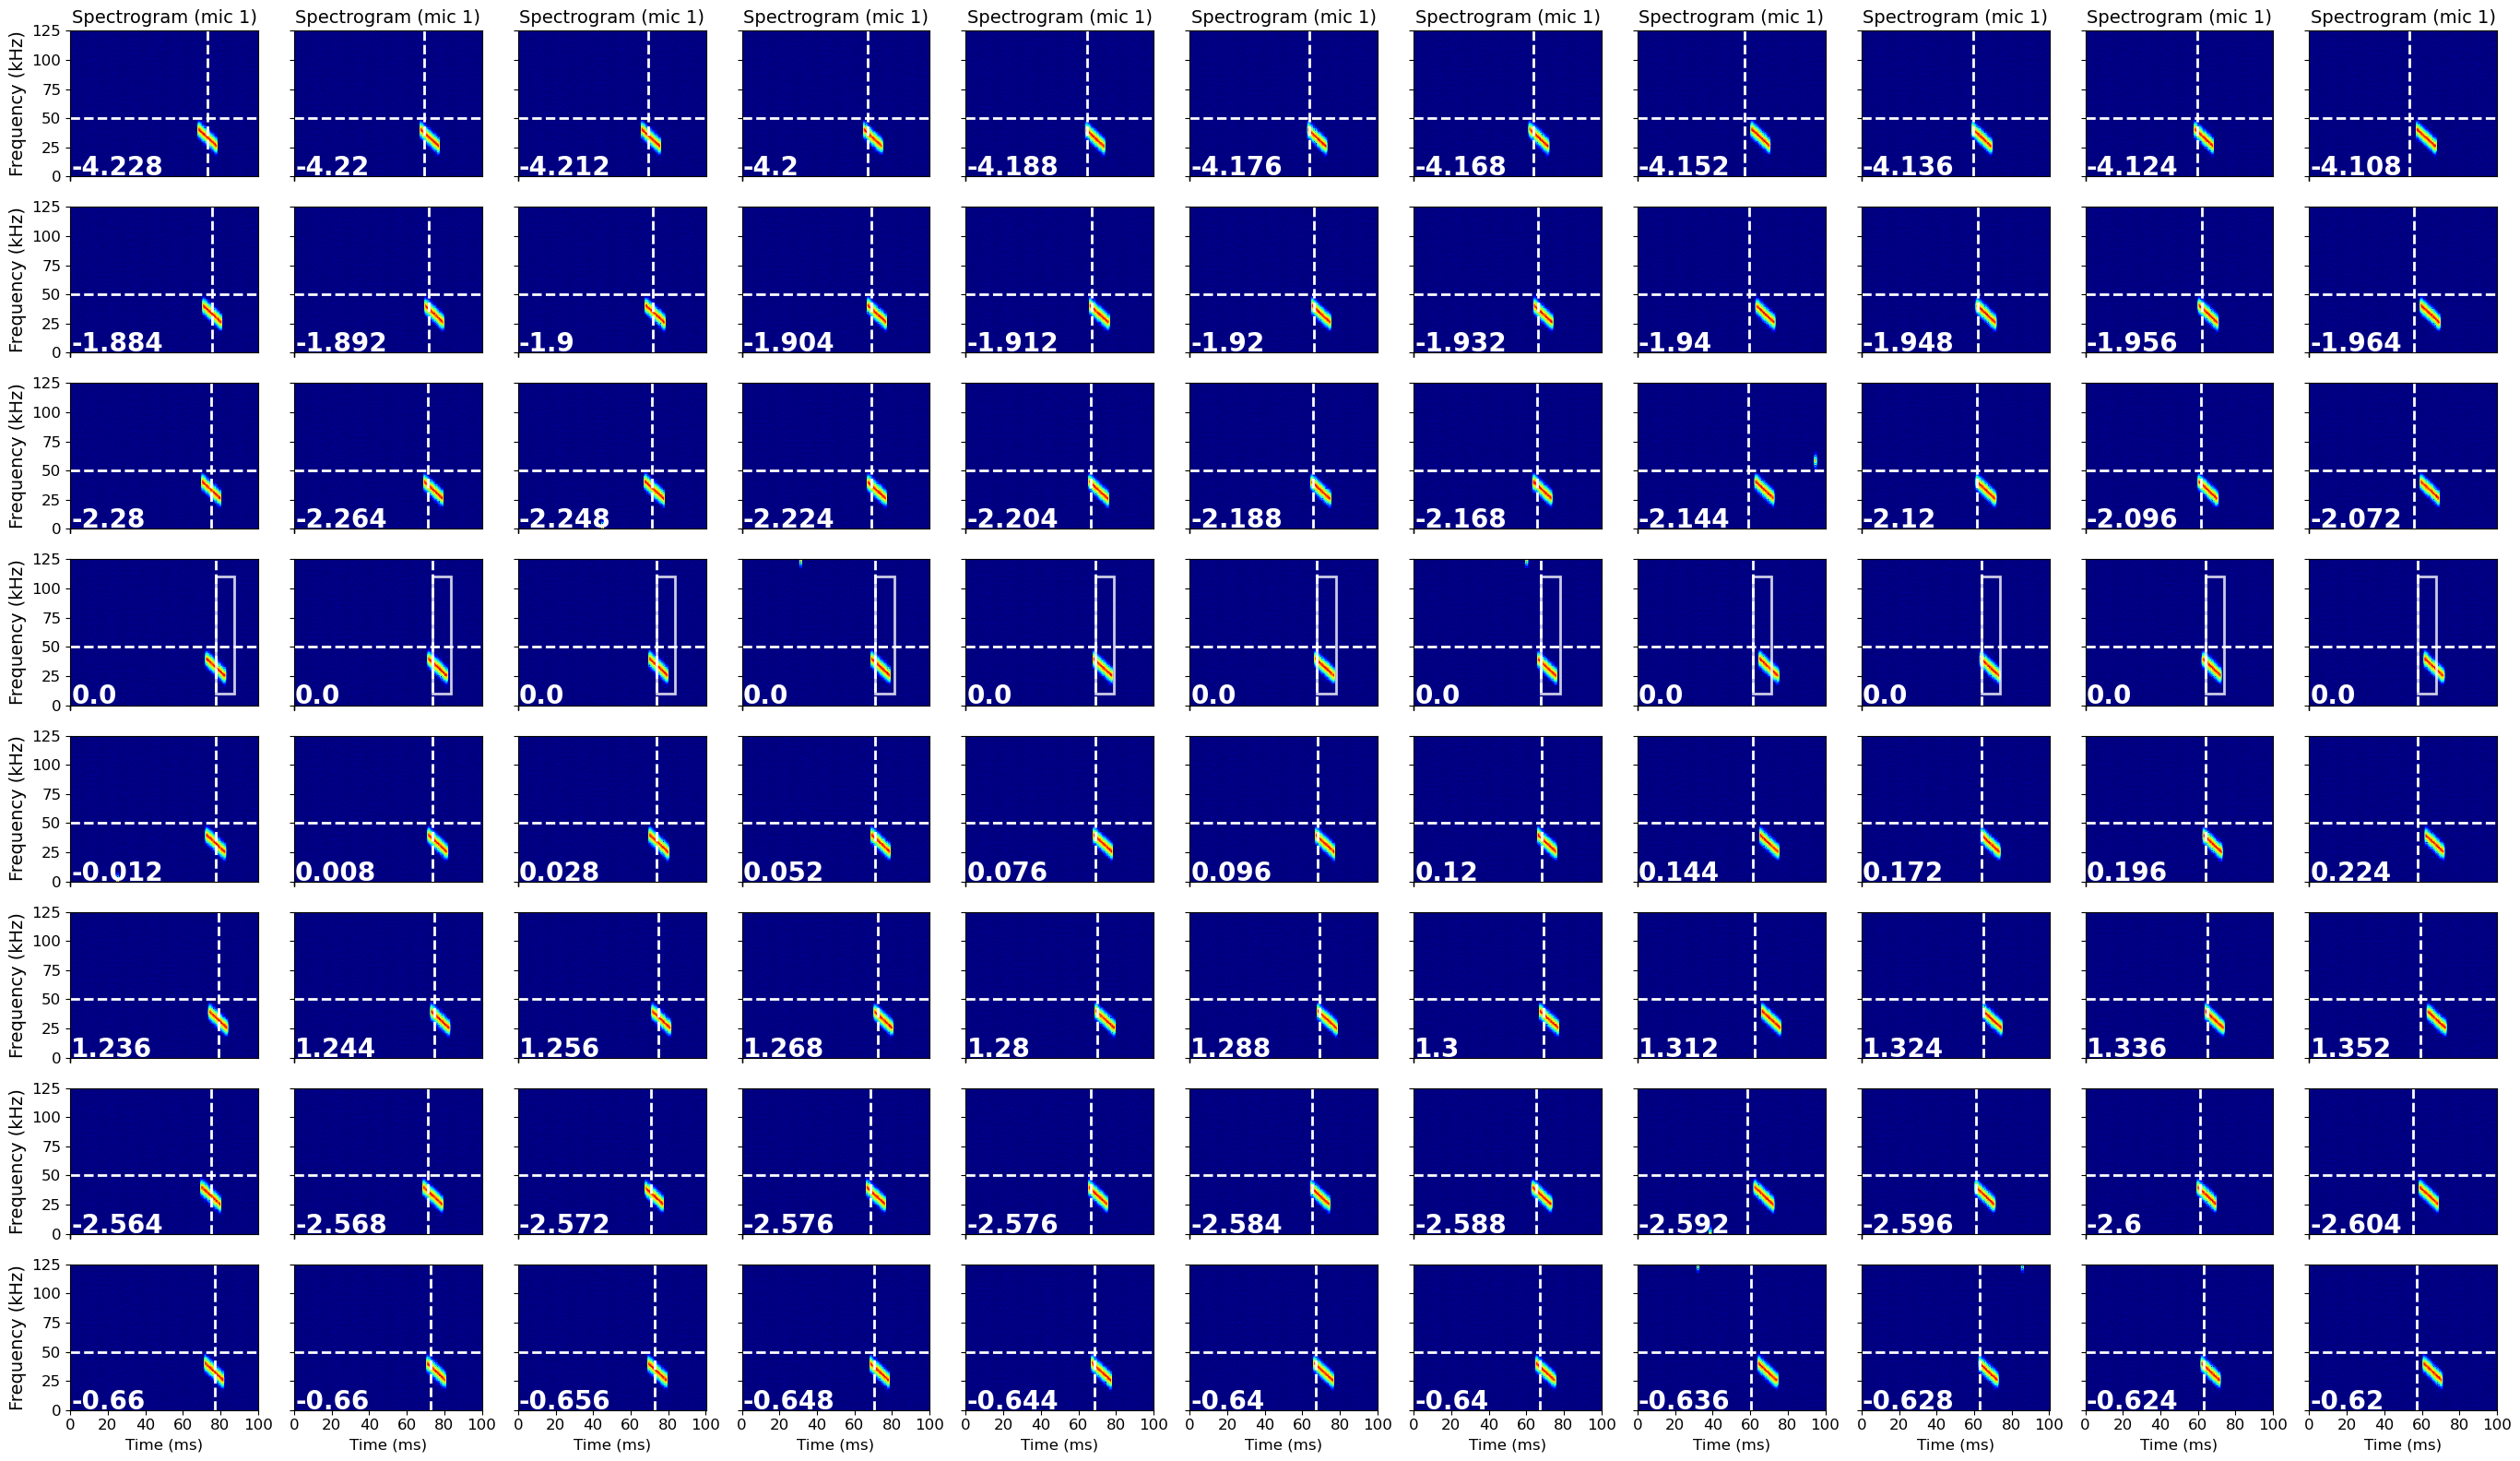

In [40]:
%matplotlib inline

example_t_delays_wrt_selected_channel = np.zeros((time_steps.size, NUM_GOOD_CHANNELS), dtype=np.float64)
channel_num = 0
plt.figure(figsize=(2.5*noisy_calls.shape[0], 2*NUM_GOOD_CHANNELS))
plt.rcParams.update({'font.size': 12})
for non_ref_call_i in range(NUM_GOOD_CHANNELS):
    for det_num in range(noisy_calls.shape[0]):
        channel_num+=1
        spec_features = dict()
        spec_features['NFFT'] = 256 # When segments are short, NFFT should also be small (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = -80
        spec_features['vmax'] = 0

        nonref_dets = noisy_calls[det_num]
        approx_call_dur = 0.01

        ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
        cleaned_template_det, fc_t = clean_section_to_remove_noise(ref_call_of_det, spec_features)
        ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(cleaned_template_det, approx_call_dur)

        signal1 = ref_call_of_det
        signal2 = ref_mic_call_only
        auto_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
        lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(auto_correlation)
        time_delay_in_samples = lags[max_lag_index]
        auto_time_delay_in_seconds = time_delay_in_samples / FS

        signal1 = nonref_dets[non_ref_call_i, :]
        cleaned_signal1, fc_t = clean_section_to_remove_noise(signal1, spec_features)
        signal2 = ref_mic_call_only
        cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
        lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(cross_correlation)
        time_delay_in_samples = lags[max_lag_index]
        time_delay_in_seconds = time_delay_in_samples / FS

        example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

        plt.subplot(NUM_GOOD_CHANNELS, noisy_calls.shape[0], channel_num)
        plt.rcParams.update({'font.size': 12})
        if non_ref_call_i==0:
            plt.title(f"Spectrogram (mic {MICROPHONES_USED[non_ref_call_i]})", fontsize=14)
        plt.specgram(cleaned_signal1+1e-6, NFFT=spec_features['NFFT'], 
                        cmap='jet', vmin=spec_features['vmin'], vmax=spec_features['vmax'], mode='magnitude', scale='dB')
        plt.text(x=(FS/2)*0.0005,y=0.85/(FS/2000),s=f'{round(1000*(time_delay_in_seconds-auto_time_delay_in_seconds), 3)}',color='w',fontsize=20,fontweight='bold')
        plt.axvline(x=(FS/2)*(time_delay_in_seconds), linestyle='dashed', linewidth=2, color='w')
        plt.axhline(y=50/(FS/2000), linestyle='dashed', linewidth=2, color='w')
        ax = plt.gca()
        if non_ref_call_i==ref_channel_num:
            rect_call = patches.Rectangle(((FS/2)*(found_call_start), (10/(FS/2000))), (FS/2)*approx_call_dur, (100/(FS/2000)), 
                            linewidth=2, edgecolor='white', facecolor='none', alpha=0.8)
            ax.add_patch(rect_call)
        if det_num==0:
            plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, FS/2000, 6).astype('int'))
            plt.ylabel("Frequency (kHz)", fontsize=14)
        else:
            plt.yticks(ticks=np.linspace(0, 1, 6), labels=['']*6)
        if non_ref_call_i==(NUM_GOOD_CHANNELS-1):
            plt.xticks(ticks=(np.linspace(0, signal_duration*(FS/2), 6)), labels=(np.linspace(0, signal_duration*1e3, 6)).astype(int), rotation=0)
            plt.xlabel("Time (ms)")    
        else:
            plt.xticks((np.linspace(0, signal_duration, 6)), labels=['']*6)

plt.tight_layout()
plt.show()

In [41]:
time_step = 8.7
time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
pos_x = x_arr[time_idx]
pos_y = y_arr[time_idx]
pos_z = z_arr[time_idx]

dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
receive_signaln_for_timestep = signal[:, None, None]
signal_duration_samples = np.arange(int(signal_duration * FS))
rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
noise_power_dB = 0 # dBFS
noise_power_lin = 10**(noise_power_dB/10)
noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)

noisy_calls = example_calls + noise_mat
noisy_calls.shape

(88, 8, 25000)

In [42]:
example_t_delays_wrt_selected_channel = np.zeros((time_steps.size, NUM_GOOD_CHANNELS), dtype=np.float64)
channel_num = 0
for non_ref_call_i in range(NUM_GOOD_CHANNELS):
    for det_num in range(noisy_calls.shape[0]):
        channel_num+=1
        nonref_dets = noisy_calls[det_num]
        approx_call_dur = 0.01

        ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
        cleaned_template_det, fc_t = clean_section_to_remove_noise(ref_call_of_det, spec_features)
        ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(cleaned_template_det, approx_call_dur)

        raw_signal1 = nonref_dets[non_ref_call_i, :]
        signal1, fc_t = clean_section_to_remove_noise(raw_signal1, spec_features)
        signal2 = ref_mic_call_only
        cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
        lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(cross_correlation)
        time_delay_in_samples = lags[max_lag_index]
        time_delay_in_seconds = time_delay_in_samples / FS

        example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

In [43]:
time_received_at_rn = example_t_delays_wrt_selected_channel[:time_idx]
t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

In [44]:
norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]), dtype=np.float64)
cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0], dtype=np.float64)
for i in range(measured_d_mics_to_ref.shape[0]):
    measured_dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
    num_noise = 1000
    dm0_columns = (measured_dm0_column + np.random.normal(loc=0, scale=1e-3, size=(NUM_NONREFCHANNELS, num_noise)))
    xs_estimates = np.zeros((num_noise, 4))
    for j in range(num_noise):
        dm0_column = dm0_columns[:,j].reshape((NUM_NONREFCHANNELS, 1))
        A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), dm0_column))
        wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (dm0_column**2))/2
        xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
        xs_estimates[j,:] = xs[:,0]

    mean_xs = np.mean(xs_estimates, axis=0)
    source_locs[:,i] = mean_xs.reshape((1,4))
    cond_a_vals[i] = np.linalg.cond(A_mat)
    line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))

    valid_source_locs = source_locs[:,np.abs(source_locs[3,:])>0.5]

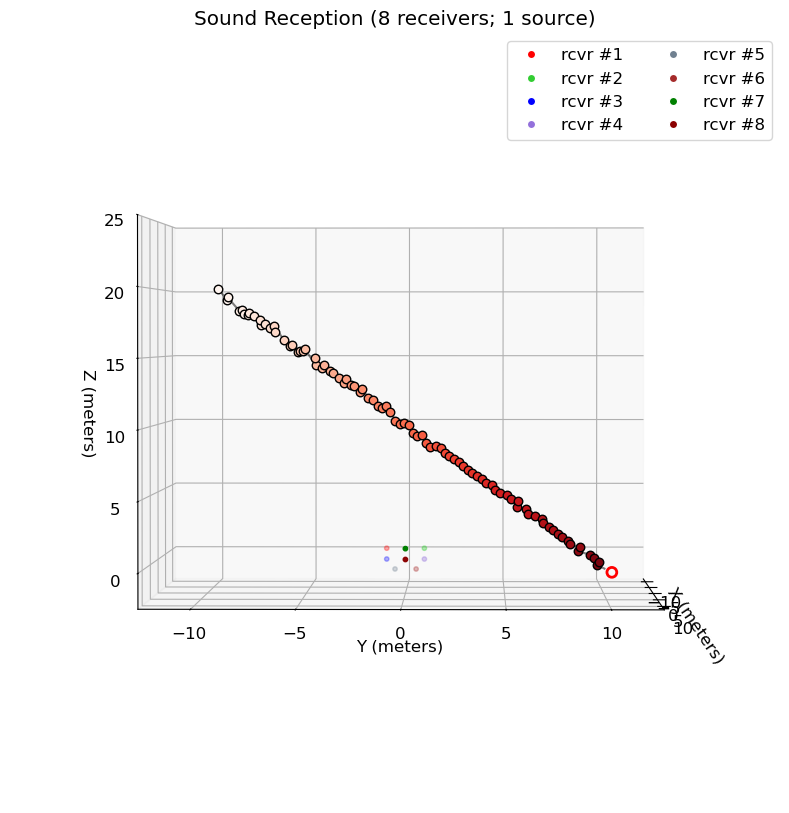

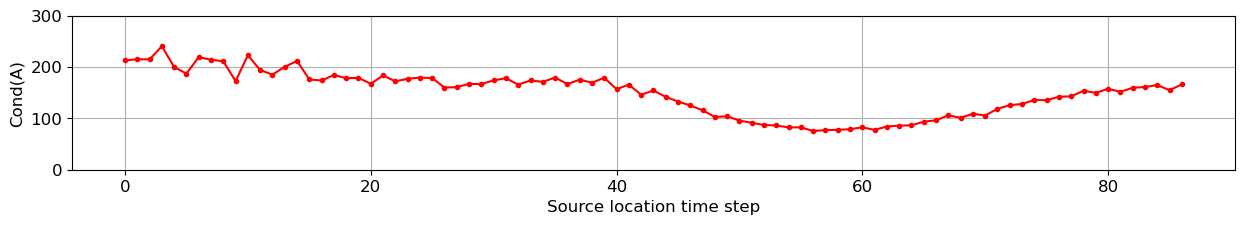

In [45]:
fig = plt.figure(figsize=(15, 10))
plt.rcParams.update({'font.size':12})
marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
map_ax_3d = fig.add_subplot(projection='3d')
map_ax_3d.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])

norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
for i in range(measured_d_mics_to_ref.shape[0]-1):
    line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
    map_ax_3d.scatter(source_locs[0,i], source_locs[1,i], 
                        source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    
map_ax_3d.scatter(pos_x, pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
map_ax_3d.plot(source_locs[0,:], source_locs[1,:], source_locs[2,:], color='k', alpha=0.5, zorder=1)
map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE)
map_ax_3d.set_xlabel("X (meters)")
map_ax_3d.set_ylabel("Y (meters)")
map_ax_3d.set_zlabel("Z (meters)")
map_ax_3d.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
map_ax_3d.legend(handles=marker_handles, ncol=2, loc='upper right')
map_ax_3d.view_init(elev=1, azim=1)

plt.figure(figsize=(15, 2))
plt.plot(cond_a_vals, marker='.')
plt.grid(which='both')
plt.ylabel('Cond(A)')
plt.xlabel('Source location time step')
plt.ylim(0, 300)

plt.show()

In [46]:
delta_source_loc = source_locs[:3,1:] - source_locs[:3,:-1]
delta_t = ASSUMED_BAT_IPI
measured_velocity = np.sqrt(np.sum((delta_source_loc**2),axis=0)) / delta_t
measured_velocity

array([11.1254164 ,  1.92503258, 13.23906019,  4.68636169,  3.83925067,
        6.34533008,  1.7578043 ,  4.09599118,  8.4927715 ,  3.39852475,
        3.9519348 ,  5.37389868,  4.91803217,  4.927307  , 13.73168093,
        5.79507229,  1.95795115,  7.38551601,  1.78656975,  2.79924106,
        2.00303059, 14.02555799,  5.50248793,  9.4590007 ,  2.62196896,
        6.42988335,  3.20746028,  5.47029459,  5.07706875,  3.49036296,
        5.53721242,  2.90944183,  6.17639905,  3.67917763,  7.97908367,
        3.38164842,  5.70881859,  3.36295363,  3.49043957,  5.23223539,
        7.64481051,  3.75886738,  3.64140316,  3.88092853,  6.53863769,
        3.74263157,  3.75561692,  5.75179695,  4.22620765,  4.40254449,
        4.01781849,  4.23736869,  4.06636632,  4.12717295,  3.8902551 ,
        4.2831384 ,  4.01555517,  3.96291709,  3.9714262 ,  4.0714282 ,
        3.95850671,  4.44214644,  3.93787645,  3.90843359,  5.74643622,
        3.74550312,  5.00332942,  4.59436636,  6.72784419,  3.48

In [47]:
true_time_delay_mics_to_selected_ref_channel = ((dist_from_source_to_r_n_arr[:,:] / SOUND_SPEED_AIR) - (dist_from_source_to_r_n_arr[SELECTED_CHANNEL_FOR_REF,:] / SOUND_SPEED_AIR)).T
true_d_mics_to_ref = np.delete(true_time_delay_mics_to_selected_ref_channel * SOUND_SPEED_AIR, IND_OF_SELECTED_CHANNEL, axis=1)

norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
source_locs = np.zeros((4, true_d_mics_to_ref.shape[0]), dtype=np.float64)
cond_a_vals = np.zeros(true_d_mics_to_ref.shape[0], dtype=np.float64)
for i in range(true_d_mics_to_ref.shape[0]):
    measured_dm0_column = true_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
    num_noise = 1000
    dm0_columns = (measured_dm0_column + np.random.normal(loc=0, scale=1e-3, size=(NUM_NONREFCHANNELS, num_noise)))
    xs_estimates = np.zeros((num_noise, 4))
    for j in range(num_noise):
        dm0_column = dm0_columns[:,j].reshape((NUM_NONREFCHANNELS, 1))
        A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), dm0_column))
        wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (dm0_column**2))/2
        xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
        xs_estimates[j,:] = xs[:,0]

    mean_xs = np.mean(xs_estimates, axis=0)
    source_locs[:,i] = mean_xs.reshape((1,4))
    cond_a_vals[i] = np.linalg.cond(A_mat)
    line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))

    valid_source_locs = source_locs[:,np.abs(source_locs[3,:])>0.5]

In [48]:
true_time_delay_mics_to_selected_ref_channel

array([[-3.56936411e-03, -1.22325484e-03, -1.62117586e-03,
         6.61546129e-04,  6.49606244e-04,  1.89709816e-03,
        -1.90273659e-03,  0.00000000e+00],
       [-3.56319912e-03, -1.23412434e-03, -1.60703481e-03,
         6.57874957e-04,  6.66386308e-04,  1.90356644e-03,
        -1.91019287e-03,  0.00000000e+00],
       [-3.55670834e-03, -1.24530624e-03, -1.59238512e-03,
         6.54067411e-04,  6.83668020e-04,  1.91017437e-03,
        -1.91783019e-03,  0.00000000e+00],
       [-3.54987007e-03, -1.25681296e-03, -1.57720092e-03,
         6.50116304e-04,  7.01472212e-04,  1.91692491e-03,
        -1.92565372e-03,  0.00000000e+00],
       [-3.54266085e-03, -1.26865746e-03, -1.56145470e-03,
         6.46013971e-04,  7.19820736e-04,  1.92382094e-03,
        -1.93366870e-03,  0.00000000e+00],
       [-3.53505534e-03, -1.28085329e-03, -1.54511719e-03,
         6.41752232e-04,  7.38736518e-04,  1.93086525e-03,
        -1.94188039e-03,  0.00000000e+00],
       [-3.52702612e-03, -1.293414

In [49]:
delta_source_loc = valid_source_locs[:3,1:] - valid_source_locs[:3,:-1]
delta_t = ASSUMED_BAT_IPI
true_velocity = np.sqrt(np.sum((delta_source_loc**2),axis=0)) / delta_t
true_velocity

array([2.92380125, 4.7167093 , 4.32808329, 3.07928536, 4.18008569,
       3.22830405, 5.22038972, 3.41774424, 3.82400257, 3.75610197,
       4.41519609, 3.47837476, 4.30043629, 4.05101309, 3.67683404,
       3.5766517 , 4.55811938, 3.88856991, 3.98889903, 3.80558962,
       3.87010257, 4.22581838, 4.04080032, 3.91891115, 3.76078545,
       4.17953839, 4.14902357, 3.80581964, 3.89337173, 3.85014548,
       4.03334093, 4.13505233, 3.85926225, 4.26962208, 3.96947916,
       3.78274054, 3.82109152, 4.0470289 , 4.0524569 , 4.12545857,
       3.92151572, 3.98385061, 3.90636854, 3.95017862, 3.96861266,
       4.00268477, 3.93023706, 3.99174946, 4.02058951, 3.93879222,
       4.02266813, 4.00220649, 3.99043829, 3.98637785, 4.00766741,
       3.99533074, 3.99784592, 3.99469804, 3.99096779, 3.9983136 ,
       4.0004516 , 3.99244738, 4.02083731, 3.9531946 , 4.02973249,
       3.93292067, 4.03072426, 4.05656542, 3.92655692, 3.99850165,
       3.93955768, 3.91244837, 4.10684845, 3.98522229, 3.94739

In [50]:
true_velocity.mean(), measured_velocity.mean()

(3.9667976430001914, 4.896822802678609)

In [52]:
def simulate_N_receivers(time_step, noise_power_dB):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    
    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]

    fig = plt.figure(figsize=(18, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=np.array([1, 1, 1]), wspace=0.3)
    map_ax_2d_xy = plt.subplot(gs[0, 0])
    map_ax_2d_xy.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xy.plot(x_arr, y_arr, color='k', alpha=0.5, zorder=1, label=f"Source")
    map_ax_2d_xy.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xy.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_xlabel("X (meters)")
    map_ax_2d_xy.set_ylabel("Y (meters)")
    map_ax_2d_xy.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_xz = plt.subplot(gs[0, 1])
    map_ax_2d_xz.scatter(rN_x, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xz.plot(x_arr, z_arr, color='k', alpha=0.5, zorder=1, label=f"Source")
    map_ax_2d_xz.scatter(pos_x, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_xz.set_xlabel("X (meters)")
    map_ax_2d_xz.set_ylabel("Z (meters)")
    map_ax_2d_xz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_yz = plt.subplot(gs[0, 2])
    map_ax_2d_yz.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_yz.plot(y_arr, z_arr, color='k', alpha=0.5, zorder=1, label=f"Source")
    map_ax_2d_yz.scatter(pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_yz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_yz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_yz.set_xlabel("Y (meters)")
    map_ax_2d_yz.set_ylabel("Z (meters)")
    map_ax_2d_yz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

noise_slider = widgets.IntSlider(
    value=-10, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…

### Simulation #1: Direct distance-to-array used

In [53]:
def simulate_N_receivers(time_step, noise_power_dB):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]

    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_from_source_to_r_n_arr = (dist_from_source_to_r_n_arr[:,:] / SOUND_SPEED_AIR)
    true_time_delay_mics_to_selected_ref_channel = (time_from_source_to_r_n_arr - time_from_source_to_r_n_arr[IND_OF_SELECTED_CHANNEL,:]).T
    true_d_mics_to_ref = np.delete(true_time_delay_mics_to_selected_ref_channel * SOUND_SPEED_AIR, IND_OF_SELECTED_CHANNEL, axis=1)

    fig = plt.figure(figsize=(18, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=np.array([1, 1, 1]), wspace=0.3)
    map_ax_2d_xy = plt.subplot(gs[0, 0])
    map_ax_2d_xy.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xy.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xy.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_xlabel("X (meters)")
    map_ax_2d_xy.set_ylabel("Y (meters)")
    map_ax_2d_xy.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_xz = plt.subplot(gs[0, 1])
    map_ax_2d_xz.scatter(rN_x, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xz.scatter(pos_x, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_xz.set_xlabel("X (meters)")
    map_ax_2d_xz.set_ylabel("Z (meters)")
    map_ax_2d_xz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_yz = plt.subplot(gs[0, 2])
    map_ax_2d_yz.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_yz.scatter(pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_yz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_yz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_yz.set_xlabel("Y (meters)")
    map_ax_2d_yz.set_ylabel("Z (meters)")
    map_ax_2d_yz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
    source_locs = np.zeros((4, true_d_mics_to_ref.shape[0]-1), dtype=np.float64)
    cond_a_vals = np.zeros(true_d_mics_to_ref.shape[0]-1, dtype=np.float64)
    for i in range(true_d_mics_to_ref.shape[0]-1):
        measured_dm0_column = true_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        num_noise = 100
        dm0_columns = (measured_dm0_column + np.random.normal(loc=0, scale=1e-3, size=(NUM_NONREFCHANNELS, num_noise)))
        xs_estimates = np.zeros((num_noise, 4))
        for j in range(num_noise):
            dm0_column = dm0_columns[:,j].reshape((NUM_NONREFCHANNELS, 1))
            A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), dm0_column))
            wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (dm0_column**2))/2
            xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
            xs_estimates[j,:] = xs[:,0]

        mean_xs = np.mean(xs_estimates, axis=0)
        source_locs[:,i] = mean_xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax_2d_xy.scatter(source_locs[0,i], source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_xz.scatter(source_locs[0,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_yz.scatter(source_locs[1,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    dist_e = np.mean(np.sqrt(((source_locs[0,:]-x_arr[:-1])**2) + ((source_locs[1,:]-y_arr[:-1])**2) + ((source_locs[2,:]-z_arr[:-1])**2)))
    map_ax_2d_xy.text(x=-10, y=9, s=f'Mean distance error\n{dist_e:.6f}')
    
    plt.figure(figsize=(18, 2))
    plt.plot(cond_a_vals, marker='.')
    plt.grid(which='both')
    plt.ylabel('Cond(A)')
    plt.xlabel('Source location time step')
    plt.ylim(0, 300)

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

noise_slider = widgets.IntSlider(
    value=-10, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…

### Simulation #2: TDOA-based method for unit impulse transmission

In [54]:
def simulate_N_receivers(time_step, noise_power_dB):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_transmitted = TIME_DURATION/2
    t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    signal = scipy.signal.unit_impulse(t.size, idx=int(time_transmitted*FS)) * 1000
    signal_duration = TIME_DURATION/2

    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]

    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)
    
    time_received_at_rn = ((np.argmax(chunk_of_received_signaln_in_window_timestep, axis=0)) / FS).T
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(18, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=np.array([1, 1, 1]), wspace=0.3)
    map_ax_2d_xy = plt.subplot(gs[0, 0])
    map_ax_2d_xy.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xy.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xy.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_xlabel("X (meters)")
    map_ax_2d_xy.set_ylabel("Y (meters)")
    map_ax_2d_xy.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_xz = plt.subplot(gs[0, 1])
    map_ax_2d_xz.scatter(rN_x, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xz.scatter(pos_x, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_xz.set_xlabel("X (meters)")
    map_ax_2d_xz.set_ylabel("Z (meters)")
    map_ax_2d_xz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_yz = plt.subplot(gs[0, 2])
    map_ax_2d_yz.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_yz.scatter(pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_yz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_yz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_yz.set_xlabel("Y (meters)")
    map_ax_2d_yz.set_ylabel("Z (meters)")
    map_ax_2d_yz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
    source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]-1), dtype=np.float64)
    cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0]-1, dtype=np.float64)
    for i in range(measured_d_mics_to_ref.shape[0]-1):
        measured_dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        num_noise = 100
        dm0_columns = (measured_dm0_column + np.random.normal(loc=0, scale=1e-3, size=(NUM_NONREFCHANNELS, num_noise)))
        xs_estimates = np.zeros((num_noise, 4))
        for j in range(num_noise):
            dm0_column = dm0_columns[:,j].reshape((NUM_NONREFCHANNELS, 1))
            A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), dm0_column))
            wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (dm0_column**2))/2
            xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
            xs_estimates[j,:] = xs[:,0]

        mean_xs = np.mean(xs_estimates, axis=0)
        source_locs[:,i] = mean_xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        
        map_ax_2d_xy.scatter(source_locs[0,i], source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_xz.scatter(source_locs[0,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_yz.scatter(source_locs[1,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    dist_e = np.mean(np.sqrt(((source_locs[0,:]-x_arr[:-1])**2) + ((source_locs[1,:]-y_arr[:-1])**2) + ((source_locs[2,:]-z_arr[:-1])**2)))
    map_ax_2d_xy.text(x=-10, y=9, s=f'Mean distance error\n{dist_e:.6f}')
    
    plt.figure(figsize=(18, 2))
    plt.plot(cond_a_vals, marker='.')
    plt.grid(which='both')
    plt.ylabel('Cond(A)')
    plt.xlabel('Source location time step')
    plt.ylim(0, 300)

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

noise_slider = widgets.IntSlider(
    value=-10, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…

### Simulation #3: TDOA-based method for downchirp transmission using GCC

In [55]:
def simulate_N_receivers(time_step, noise_power_dB):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_transmitted = TIME_DURATION/2
    t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    raw_signal = scipy.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
    template_signal = raw_signal[:int(FS*0.01)]
    signal = np.zeros(t.size)
    signal[int(FS*time_transmitted):int(FS*(time_transmitted+0.01))] = template_signal
    signal_duration = TIME_DURATION/2

    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]


    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
    noise_power_lin = 10**(noise_power_dB/10)
    noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)
    noisy_calls = example_calls + noise_mat

    example_t_delays_wrt_selected_channel = np.zeros((noisy_calls.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    for non_ref_call_i in range(NUM_GOOD_CHANNELS):
        for det_num in range(noisy_calls.shape[0]):
            nonref_dets = noisy_calls[det_num]
            approx_call_dur = 0.01
            ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
            ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)

            signal1 = nonref_dets[non_ref_call_i, :]
            signal2 = ref_mic_call_only
            cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
            lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds = time_delay_in_samples / FS
            example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

    time_received_at_rn = example_t_delays_wrt_selected_channel[:time_idx]
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(18, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=np.array([1, 1, 1]), wspace=0.3)
    map_ax_2d_xy = plt.subplot(gs[0, 0])
    map_ax_2d_xy.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xy.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xy.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_xlabel("X (meters)")
    map_ax_2d_xy.set_ylabel("Y (meters)")
    map_ax_2d_xy.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_xz = plt.subplot(gs[0, 1])
    map_ax_2d_xz.scatter(rN_x, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xz.scatter(pos_x, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_xz.set_xlabel("X (meters)")
    map_ax_2d_xz.set_ylabel("Z (meters)")
    map_ax_2d_xz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_yz = plt.subplot(gs[0, 2])
    map_ax_2d_yz.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_yz.scatter(pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_yz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_yz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_yz.set_xlabel("Y (meters)")
    map_ax_2d_yz.set_ylabel("Z (meters)")
    map_ax_2d_yz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
    source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]-1), dtype=np.float64)
    cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0]-1, dtype=np.float64)
    for i in range(measured_d_mics_to_ref.shape[0]-1):
        measured_dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        num_noise = 100
        dm0_columns = (measured_dm0_column + np.random.normal(loc=0, scale=1e-3, size=(NUM_NONREFCHANNELS, num_noise)))
        xs_estimates = np.zeros((num_noise, 4))
        for j in range(num_noise):
            dm0_column = dm0_columns[:,j].reshape((NUM_NONREFCHANNELS, 1))
            A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), dm0_column))
            wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (dm0_column**2))/2
            xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
            xs_estimates[j,:] = xs[:,0]

        mean_xs = np.mean(xs_estimates, axis=0)
        source_locs[:,i] = mean_xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        
        map_ax_2d_xy.scatter(source_locs[0,i], source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_xz.scatter(source_locs[0,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_yz.scatter(source_locs[1,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    plt.figure(figsize=(18, 2))
    plt.plot(cond_a_vals, marker='.')
    plt.grid(which='both')
    plt.ylabel('Cond(A)')
    plt.xlabel('Source location time step')
    plt.ylim(0, 300)

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

noise_slider = widgets.IntSlider(
    value=0, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…

In [57]:
def simulate_N_receivers(time_step, noise_power_dB, template_channel, elevation, azim):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_transmitted = TIME_DURATION/2
    t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    raw_signal = scipy.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
    template_signal = raw_signal[:int(FS*0.01)]
    signal = np.zeros(t.size)
    signal[int(FS*time_transmitted):int(FS*(time_transmitted+0.01))] = template_signal
    signal_duration = TIME_DURATION/2

    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]


    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
    noise_power_lin = 10**(noise_power_dB/10)
    noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)
    noisy_calls = example_calls + noise_mat

    example_t_delays_wrt_selected_channel = np.zeros((noisy_calls.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    for non_ref_call_i in range(NUM_GOOD_CHANNELS):
        for det_num in range(noisy_calls.shape[0]):
            nonref_dets = noisy_calls[det_num]
            approx_call_dur = 0.01
            ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
            ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)

            signal1 = nonref_dets[non_ref_call_i, :]
            signal2 = ref_mic_call_only
            cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
            lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds = time_delay_in_samples / FS
            example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

    time_received_at_rn = example_t_delays_wrt_selected_channel[:time_idx]
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(15, 10))
    plt.rcParams.update({'font.size':12})
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    map_ax_3d = fig.add_subplot(projection='3d')
    map_ax_3d.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])

    norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
    source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]-1), dtype=np.float64)
    cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0]-1, dtype=np.float64)
    for i in range(measured_d_mics_to_ref.shape[0]-1):
        measured_dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        num_noise = 100
        dm0_columns = (measured_dm0_column + np.random.normal(loc=0, scale=1e-3, size=(NUM_NONREFCHANNELS, num_noise)))
        xs_estimates = np.zeros((num_noise, 4))
        for j in range(num_noise):
            dm0_column = dm0_columns[:,j].reshape((NUM_NONREFCHANNELS, 1))
            A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), dm0_column))
            wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (dm0_column**2))/2
            xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
            xs_estimates[j,:] = xs[:,0]

        mean_xs = np.mean(xs_estimates, axis=0)
        source_locs[:,i] = mean_xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax_3d.scatter(source_locs[0,i], source_locs[1,i], 
                          source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        
    map_ax_3d.scatter(pos_x, pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_3d.plot(source_locs[0,:], source_locs[1,:], source_locs[2,:], color='k', alpha=0.5, zorder=1)
    map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_3d.set_xlabel("X (meters)")
    map_ax_3d.set_ylabel("Y (meters)")
    map_ax_3d.set_zlabel("Z (meters)")
    map_ax_3d.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax_3d.legend(handles=marker_handles, ncol=2, loc='upper right')
    map_ax_3d.view_init(elev=elevation, azim=azim)

    plt.figure(figsize=(15, 2))
    plt.plot(cond_a_vals, marker='.')
    plt.grid(which='both')
    plt.ylabel('Cond(A)')
    plt.xlabel('Source location time step')
    plt.ylim(0, 300)

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
noise_slider = widgets.IntSlider(
    value=-10, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)
template_slider = widgets.IntSlider(
    value=0, min=0, max=NUM_GOOD_CHANNELS-1, step=1, description="Template Channel #", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)
elevation_slider = widgets.IntSlider(
    value=1, min=0, max=360, step=1, description="Camera Elevation (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
azim_slider = widgets.IntSlider(
    value=1, min=0, max=360, step=1, description="Camera Azimuth (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider, 
                                       template_channel=template_slider, elevation=elevation_slider, azim=azim_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…

In [29]:
def simulate_N_receivers(time_step, noise_power_dB):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_transmitted = TIME_DURATION/2
    t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    raw_signal = scipy.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
    template_signal = raw_signal[:int(FS*0.01)]
    signal = np.zeros(t.size)
    signal[int(FS*time_transmitted):int(FS*(time_transmitted+0.01))] = template_signal
    signal_duration = TIME_DURATION/2

    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]


    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
    noise_power_lin = 10**(noise_power_dB/10)
    noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)
    noisy_calls = example_calls + noise_mat

    example_t_delays_wrt_selected_channel = np.zeros((noisy_calls.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    for non_ref_call_i in range(NUM_GOOD_CHANNELS):
        for det_num in range(noisy_calls.shape[0]):
            nonref_dets = noisy_calls[det_num]
            approx_call_dur = 0.01
            ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
            cleaned_template_det, fc_t = clean_section_to_remove_noise(ref_call_of_det, spec_features)
            ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(cleaned_template_det, approx_call_dur)

            raw_signal1 = nonref_dets[non_ref_call_i, :]
            signal1, fc_t = clean_section_to_remove_noise(raw_signal1, spec_features)
            signal2 = ref_mic_call_only
            cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
            lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds = time_delay_in_samples / FS
            example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

    time_received_at_rn = example_t_delays_wrt_selected_channel[:time_idx]
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(18, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=np.array([1, 1, 1]), wspace=0.3)
    map_ax_2d_xy = plt.subplot(gs[0, 0])
    map_ax_2d_xy.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xy.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xy.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_xlabel("X (meters)")
    map_ax_2d_xy.set_ylabel("Y (meters)")
    map_ax_2d_xy.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_xz = plt.subplot(gs[0, 1])
    map_ax_2d_xz.scatter(rN_x, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xz.scatter(pos_x, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_xz.set_xlabel("X (meters)")
    map_ax_2d_xz.set_ylabel("Z (meters)")
    map_ax_2d_xz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_yz = plt.subplot(gs[0, 2])
    map_ax_2d_yz.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_yz.scatter(pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_yz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_yz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_yz.set_xlabel("Y (meters)")
    map_ax_2d_yz.set_ylabel("Z (meters)")
    map_ax_2d_yz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
    source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]-1), dtype=np.float64)
    cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0]-1, dtype=np.float64)
    for i in range(measured_d_mics_to_ref.shape[0]-1):
        measured_dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        num_noise = 100
        dm0_columns = (measured_dm0_column + np.random.normal(loc=0, scale=1e-3, size=num_noise))
        xs_estimates = np.zeros((num_noise, 4))
        for j in range(num_noise):
            dm0_column = dm0_columns[:,j].reshape((NUM_NONREFCHANNELS, 1))
            A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), dm0_column))
            wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (dm0_column**2))/2
            xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
            xs_estimates[j,:] = xs[:,0]

        mean_xs = np.mean(xs_estimates, axis=0)
        source_locs[:,i] = mean_xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax_2d_xy.scatter(source_locs[0,i], source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_xz.scatter(source_locs[0,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_yz.scatter(source_locs[1,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    plt.figure(figsize=(18, 2))
    plt.plot(cond_a_vals, marker='.')
    plt.grid(which='both')
    plt.ylabel('Cond(A)')
    plt.xlabel('Source location time step')
    plt.ylim(0, 300)

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

noise_slider = widgets.IntSlider(
    value=0, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…

In [30]:
def simulate_N_receivers(time_step, noise_power_dB, template_channel, elevation, azim):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    # time_transmitted = TIME_DURATION/2
    # t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    # signal = scipy.signal.unit_impulse(t.size, idx=int(time_transmitted*FS)) * 1000
    # signal_duration = TIME_DURATION/2
    
    time_transmitted = TIME_DURATION/2
    t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    raw_signal = scipy.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
    template_signal = raw_signal[:int(FS*0.01)]
    signal = np.zeros(t.size)
    signal[int(FS*time_transmitted):int(FS*(time_transmitted+0.01))] = template_signal
    signal_duration = TIME_DURATION/2

    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]


    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
    noise_power_lin = 10**(noise_power_dB/10)
    noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)
    noisy_calls = example_calls + noise_mat

    example_t_delays_wrt_selected_channel = np.zeros((noisy_calls.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    for non_ref_call_i in range(NUM_GOOD_CHANNELS):
        for det_num in range(noisy_calls.shape[0]):
            nonref_dets = noisy_calls[det_num]
            approx_call_dur = 0.01
            ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
            cleaned_template_det, fc_t = clean_section_to_remove_noise(ref_call_of_det, spec_features)
            ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(cleaned_template_det, approx_call_dur)

            raw_signal1 = nonref_dets[non_ref_call_i, :]
            signal1, fc_t = clean_section_to_remove_noise(raw_signal1, spec_features)
            signal2 = ref_mic_call_only
            cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
            lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds = time_delay_in_samples / FS
            example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

    time_received_at_rn = example_t_delays_wrt_selected_channel[:time_idx]
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    time_from_source_to_r_n_arr = (dist_from_source_to_r_n_arr[:,:] / SOUND_SPEED_AIR)
    true_time_delay_mics_to_selected_ref_channel = (time_from_source_to_r_n_arr - time_from_source_to_r_n_arr[IND_OF_SELECTED_CHANNEL,:]).T
    true_d_mics_to_ref = np.delete(true_time_delay_mics_to_selected_ref_channel * SOUND_SPEED_AIR, IND_OF_SELECTED_CHANNEL, axis=1)

    fig = plt.figure(figsize=(15, 10))
    plt.rcParams.update({'font.size':12})
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    map_ax_3d = fig.add_subplot(projection='3d')
    map_ax_3d.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])

    norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
    source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]-1), dtype=np.float64)
    cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0]-1, dtype=np.float64)
    for i in range(measured_d_mics_to_ref.shape[0]-1):
        measured_dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        num_noise = 100
        dm0_columns = (measured_dm0_column + np.random.normal(loc=0, scale=1e-3, size=num_noise))
        xs_estimates = np.zeros((num_noise, 4))
        for j in range(num_noise):
            dm0_column = dm0_columns[:,j].reshape((NUM_NONREFCHANNELS, 1))
            A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), dm0_column))
            wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (dm0_column**2))/2
            xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
            xs_estimates[j,:] = xs[:,0]

        mean_xs = np.mean(xs_estimates, axis=0)
        source_locs[:,i] = mean_xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax_3d.scatter(source_locs[0,i], source_locs[1,i], 
                          source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        
    map_ax_3d.scatter(pos_x, pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_3d.plot(source_locs[0,:], source_locs[1,:], source_locs[2,:], color='k', alpha=0.5, zorder=1)
    map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_3d.set_xlabel("X (meters)")
    map_ax_3d.set_ylabel("Y (meters)")
    map_ax_3d.set_zlabel("Z (meters)")
    map_ax_3d.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax_3d.legend(handles=marker_handles, ncol=2, loc='upper right')
    map_ax_3d.view_init(elev=elevation, azim=azim)

    plt.figure(figsize=(15, 2))
    plt.plot(cond_a_vals, marker='.')
    plt.grid(which='both')
    plt.ylabel('Cond(A)')
    plt.xlabel('Source location time step')
    plt.ylim(0, 300)

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
noise_slider = widgets.IntSlider(
    value=0, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)
template_slider = widgets.IntSlider(
    value=0, min=0, max=NUM_GOOD_CHANNELS-1, step=1, description="Template Channel #", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)
elevation_slider = widgets.IntSlider(
    value=1, min=0, max=360, step=1, description="Camera Elevation (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
azim_slider = widgets.IntSlider(
    value=1, min=0, max=360, step=1, description="Camera Azimuth (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider, 
                                       template_channel=template_slider, elevation=elevation_slider, azim=azim_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…